In [1]:
import pandas as pd
monday = pd.read_csv("MondayWorkingHours_pcap_ISCX.csv")


In [3]:
tuesday = pd.read_csv("Tuesday-WorkingHours_pcap_ISCX.csv")


In [5]:
# === WEDNESDAY ===
wednesday = pd.read_csv("Wednesday-workingHours_pcap_ISCX.csv")

# === THURSDAY ===
thursday_morning = pd.read_csv("Thursday-WorkingHours-Morning-WebAttacks_pcap_ISCX.csv")
thursday_afternoon = pd.read_csv("Thursday-WorkingHours-Afternoon-Infilteration_pcap_ISCX.csv")

# === FRIDAY ===
friday_morning = pd.read_csv("Friday-WorkingHours-Morning_pcap_ISCX.csv")
friday_afternoon_ddos = pd.read_csv("Friday-WorkingHours-Afternoon-DDos_pcap_ISCX.csv")
friday_afternoon_portscan = pd.read_csv("Friday-WorkingHours-Afternoon-PortScan_pcap_ISCX.csv")

# Print confirmation
print("Datasets loaded successfully:")
print("Monday:", monday.shape)
print("Tuesday:", tuesday.shape)
print("Wednesday:", wednesday.shape)
print("Thursday Morning:", thursday_morning.shape)
print("Thursday Afternoon:", thursday_afternoon.shape)
print("Friday Morning:", friday_morning.shape)
print("Friday Afternoon DDoS:", friday_afternoon_ddos.shape)
print("Friday Afternoon PortScan:", friday_afternoon_portscan.shape)

Datasets loaded successfully:
Monday: (529918, 79)
Tuesday: (445909, 79)
Wednesday: (692703, 79)
Thursday Morning: (170366, 79)
Thursday Afternoon: (288602, 79)
Friday Morning: (191033, 79)
Friday Afternoon DDoS: (225745, 79)
Friday Afternoon PortScan: (286467, 79)


In [7]:
# Benign → Safe (0)
monday["Attack_Type"] = "Safe"
tuesday["Attack_Type"] = "Safe"
wednesday["Attack_Type"] = "Safe"
friday_morning["Attack_Type"] = "Safe"

# All attacks → Not Safe (1)
thursday_morning["Attack_Type"] = "Not Safe"         # Web Attack
thursday_afternoon["Attack_Type"] = "Not Safe"       # Infiltration
friday_afternoon_ddos["Attack_Type"] = "Not Safe"    # DDoS
friday_afternoon_portscan["Attack_Type"] = "Not Safe" # PortScan


In [9]:
full_df = pd.concat([
    monday,
    tuesday,
    wednesday,
    thursday_morning,
    thursday_afternoon,
    friday_morning,
    friday_afternoon_ddos,
    friday_afternoon_portscan
], ignore_index=True)

print("Final combined dataset shape:", full_df.shape)


Final combined dataset shape: (2830743, 80)


In [11]:
print(full_df.head())
full_df["Attack_Type"].unique().sum()

    Destination Port   Flow Duration   Total Fwd Packets  \
0              49188               4                   2   
1              49188               1                   2   
2              49188               1                   2   
3              49188               1                   2   
4              49486               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        0                           12   
2                        0                           12   
3                        0                           12   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             0                       6   
2                             0                       6   
3                             0                 

'SafeNot Safe'

In [13]:
# Replace Infinity
full_df.replace([float("inf"), float("-inf")], 0, inplace=True)

# Fill NaN values
full_df.fillna(0, inplace=True)

# Drop non-numeric columns except labels
non_numeric = full_df.select_dtypes(include=['object']).columns
non_numeric = [c for c in non_numeric if c != "Attack_Type" and c != "Label"]
full_df.drop(columns=non_numeric, inplace=True)

print("Clean shape:", full_df.shape)


Clean shape: (2830743, 79)


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
full_df["Attack_Type"] = le.fit_transform(full_df["Attack_Type"])

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Not Safe': 0, 'Safe': 1}


In [18]:
full_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack_Type
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,1
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,1
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,1
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,1
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,1


In [20]:
object_columns_df = full_df.select_dtypes(include=['object'])
object_column_names = object_columns_df.columns.tolist()

In [22]:
object_column_names

[]

In [26]:
full_df['Attack_Type'].unique().sum()

1

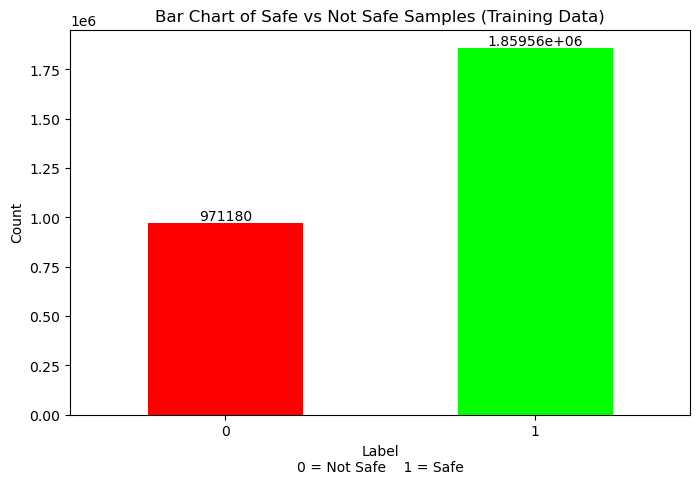

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the value counts
counts = full_df['Attack_Type'].value_counts().sort_index()  
# Ensures 0 appears before 1

# Color mapping: 0 = Not Safe (Red), 1 = Safe (Green)
bar_colors = ['#FF0000', '#00FF00']   # Red, Green

# Plot the counts
ax = counts.plot.bar(color=bar_colors, figsize=(8,5))

# Add data labels
ax.bar_label(ax.containers[0])

# Labels
plt.xlabel('Label\n0 = Not Safe    1 = Safe')
plt.ylabel('Count')
plt.title('Bar Chart of Safe vs Not Safe Samples (Training Data)')
plt.xticks(rotation=0)
plt.show()


In [34]:
X = full_df.drop("Attack_Type", axis=1)   # all features
y = full_df["Attack_Type"]                # label column


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y            # keeps the class balance same in train/test
)

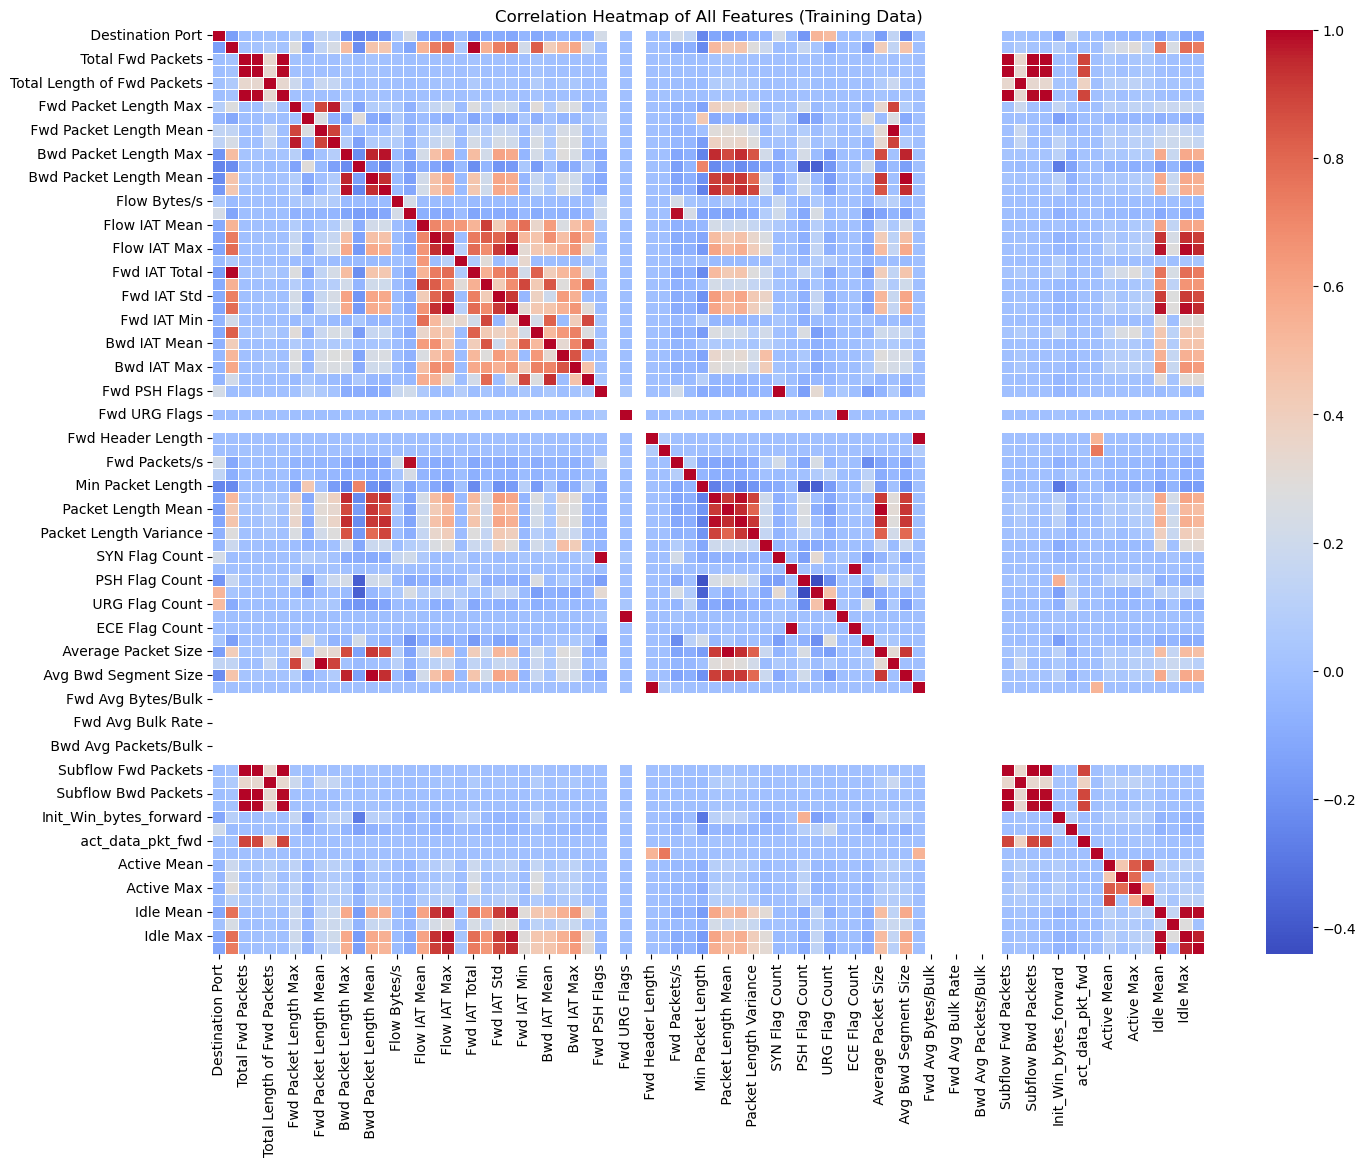

In [38]:
import seaborn as sns
corr_matrix = X_train.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))  # Large size for readability
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap of All Features (Training Data)')
plt.show()

In [40]:
corr_with_target = full_df.corr(numeric_only=True)['Attack_Type'].abs().sort_values()
corr_with_target


 Subflow Fwd Bytes             0.000280
Total Length of Fwd Packets    0.000281
 Fwd Header Length             0.000898
 Fwd Header Length.1           0.000898
 Fwd Packet Length Min         0.001159
                                 ...   
 Fwd Avg Packets/Bulk               NaN
 Fwd Avg Bulk Rate                  NaN
 Bwd Avg Bytes/Bulk                 NaN
 Bwd Avg Packets/Bulk               NaN
Bwd Avg Bulk Rate                   NaN
Name: Attack_Type, Length: 79, dtype: float64

In [42]:
low_corr_features = corr_with_target[corr_with_target < 0.02].index.tolist()
low_corr_features


[' Subflow Fwd Bytes',
 'Total Length of Fwd Packets',
 ' Fwd Header Length',
 ' Fwd Header Length.1',
 ' Fwd Packet Length Min',
 ' act_data_pkt_fwd',
 ' Bwd Header Length',
 ' min_seg_size_forward',
 'Init_Win_bytes_forward',
 ' Subflow Bwd Bytes',
 ' Total Length of Bwd Packets',
 ' Total Backward Packets',
 ' Subflow Bwd Packets',
 ' RST Flag Count',
 ' ECE Flag Count',
 'Subflow Fwd Packets',
 ' Total Fwd Packets',
 'Active Mean',
 'Bwd Packet Length Max',
 'Flow Bytes/s',
 ' Destination Port',
 ' URG Flag Count',
 ' Active Max',
 ' Bwd Packet Length Mean',
 ' Avg Bwd Segment Size',
 ' Packet Length Mean',
 ' Active Min',
 ' Fwd Packet Length Max',
 ' Average Packet Size',
 ' Fwd URG Flags',
 ' CWE Flag Count',
 ' Max Packet Length',
 ' Bwd Packet Length Std',
 ' Active Std']

In [44]:
full_df.drop(columns=low_corr_features,axis=1,inplace=True)

In [46]:
import numpy as np

# Replace inf and -inf with NaN
full_df = full_df.replace([np.inf, -np.inf], np.nan)

# Replace NaN with 0 OR column mean (safer)
full_df = full_df.fillna(0)


In [48]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0)
selector.fit(full_df)

zero_var_cols = full_df.columns[selector.get_support()==False].tolist()
zero_var_cols


[' Bwd PSH Flags',
 ' Bwd URG Flags',
 'Fwd Avg Bytes/Bulk',
 ' Fwd Avg Packets/Bulk',
 ' Fwd Avg Bulk Rate',
 ' Bwd Avg Bytes/Bulk',
 ' Bwd Avg Packets/Bulk',
 'Bwd Avg Bulk Rate']

In [50]:
full_df.drop(columns=zero_var_cols,axis=1,inplace=True)

In [52]:
full_df.head()

,Flow Duration,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Min,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,...,PSH Flag Count,ACK Flag Count,Down/Up Ratio,Avg Fwd Segment Size,Init_Win_bytes_backward,Idle Mean,Idle Std,Idle Max,Idle Min,Attack_Type
0,4,6.0,0.0,0,5.000000e+05,4.0,0.0,4,4,4,...,0,1,0,6.0,-1,0.0,0.0,0,0,1
1,1,6.0,0.0,0,2.000000e+06,1.0,0.0,1,1,1,...,0,1,0,6.0,-1,0.0,0.0,0,0,1
2,1,6.0,0.0,0,2.000000e+06,1.0,0.0,1,1,1,...,0,1,0,6.0,-1,0.0,0.0,0,0,1
3,1,6.0,0.0,0,2.000000e+06,1.0,0.0,1,1,1,...,0,1,0,6.0,-1,0.0,0.0,0,0,1
4,3,6.0,0.0,0,6.666667e+05,3.0,0.0,3,3,3,...,0,1,0,6.0,-1,0.0,0.0,0,0,1


In [54]:
full_df.shape

(2830743, 37)

In [56]:
X = full_df.drop("Attack_Type", axis=1)   # all features
y = full_df["Attack_Type"]                # label column


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y            # keeps the class balance same in train/test
)

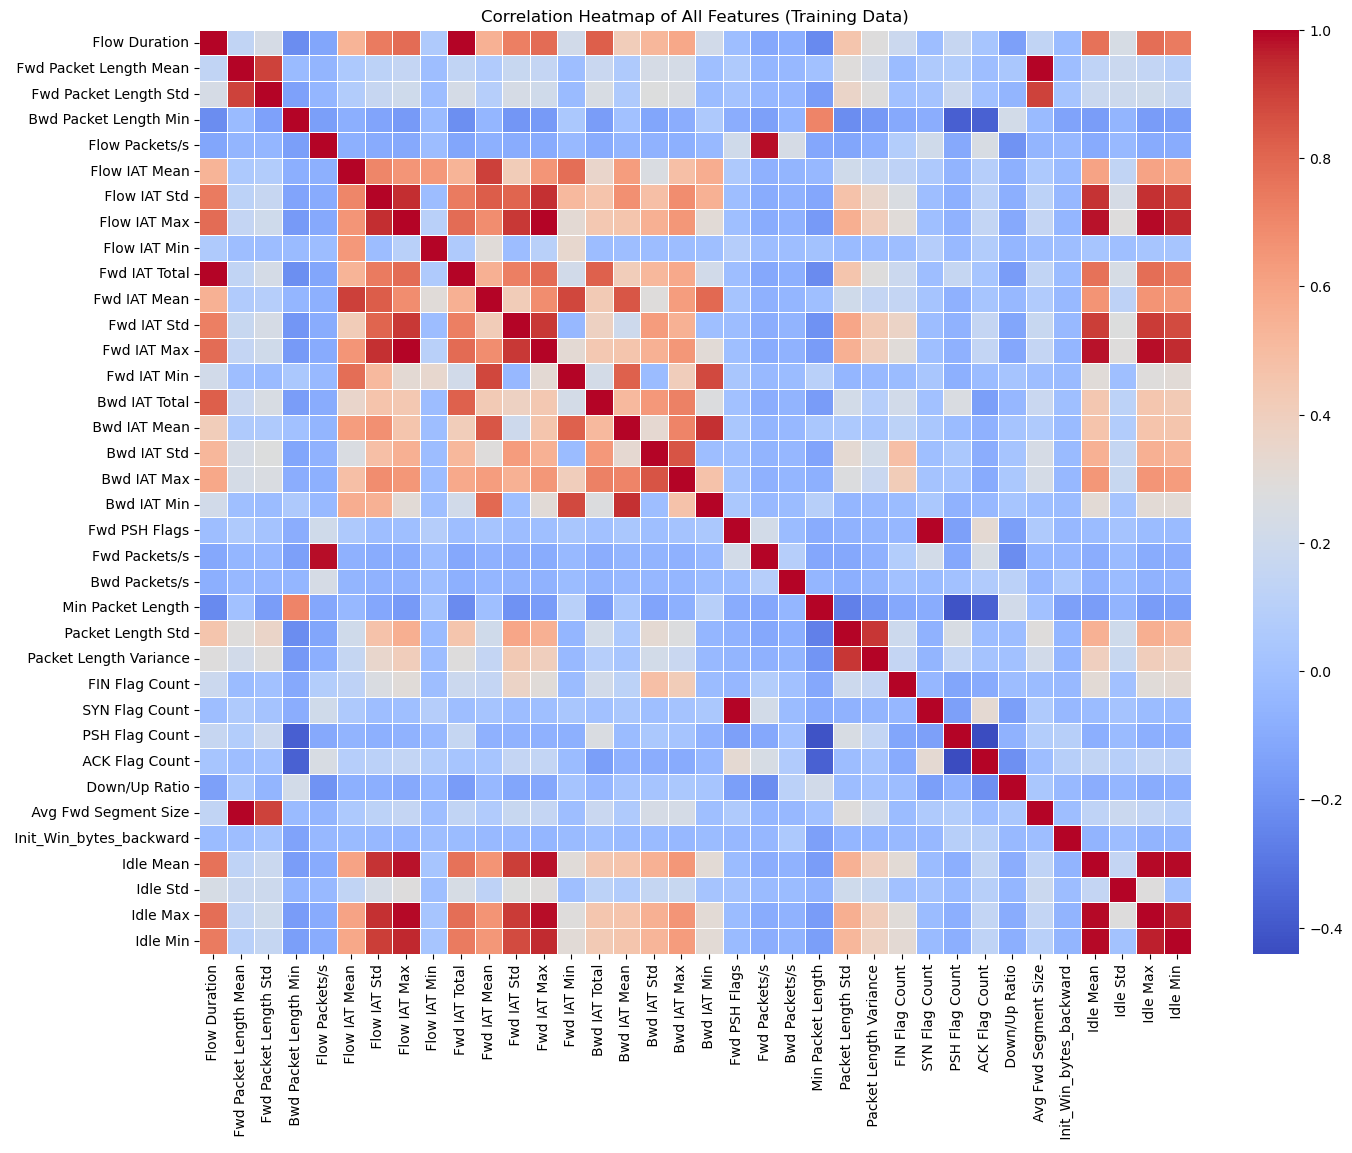

In [60]:
import seaborn as sns
corr_matrix = X_train.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))  # Large size for readability
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap of All Features (Training Data)')
plt.show()

In [62]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Step 1: Undersample majority
rus = RandomUnderSampler(random_state=42)
X_train_small, y_train_small = rus.fit_resample(X_train, y_train)

# Step 2: SMOTE on small dataset
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_small, y_train_small)


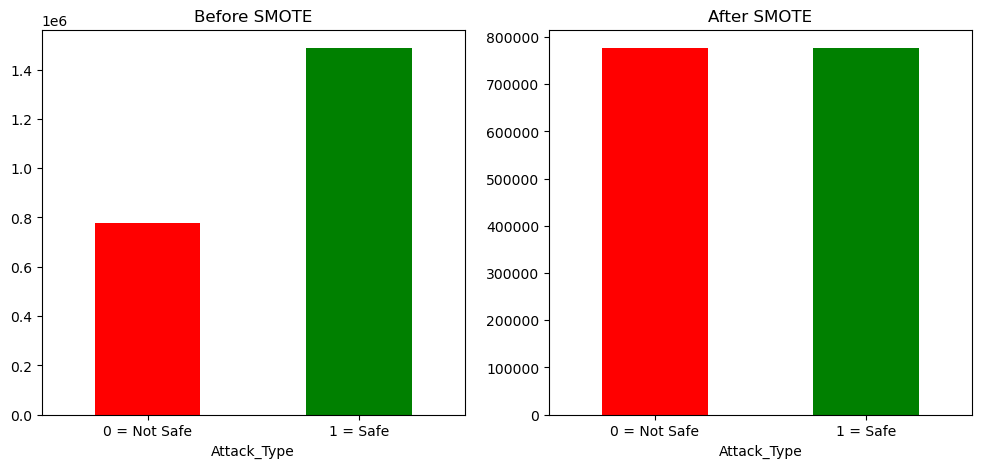

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
y_train.value_counts().sort_index().plot.bar(
    color=["red", "green"], ax=ax[0], title="Before SMOTE"
)
ax[0].set_xticklabels(["0 = Not Safe", "1 = Safe"], rotation=0)

# After SMOTE
y_train_res.value_counts().sort_index().plot.bar(
    color=["red", "green"], ax=ax[1], title="After SMOTE"
)
ax[1].set_xticklabels(["0 = Not Safe", "1 = Safe"], rotation=0)

plt.show()


In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train_res)

X_train_scaled = scaler.transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


In [70]:
pd.DataFrame(X_train_scaled).describe()


,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
count,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,...,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06,1.553888e+06
mean,1.016963e-17,-1.578671e-16,-9.310884e-17,2.992360e-17,-1.670673e-16,-2.004661e-16,1.960764e-17,2.436322e-17,-1.719326e-18,-2.728973e-17,...,-4.912884e-17,7.111427e-17,-5.231142e-17,-3.102104e-17,-1.578671e-16,-3.372806e-17,2.165620e-17,-5.253091e-17,3.950793e-17,-4.726319e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-4.214133e-01,-2.899625e-01,-2.244781e-01,-5.822907e-01,-8.353081e+00,-2.813269e-01,-3.500752e-01,-3.605545e-01,-5.066227e-02,-4.127845e-01,...,-2.121605e-01,-7.043312e-01,-6.623664e-01,-9.717282e-01,-2.899625e-01,-2.252939e-01,-3.365752e-01,-1.177490e-01,-3.417532e-01,-3.207110e-01
25%,-4.214094e-01,-2.609916e-01,-2.244781e-01,-5.822907e-01,-2.779272e-01,-2.813094e-01,-3.500752e-01,-3.605496e-01,-5.065627e-02,-4.127845e-01,...,-2.121605e-01,-7.043312e-01,-6.623664e-01,-9.717282e-01,-2.609916e-01,-2.252939e-01,-3.365752e-01,-1.177490e-01,-3.417532e-01,-3.207110e-01
50%,-4.204595e-01,-1.354514e-01,-2.244781e-01,-4.932636e-01,-2.774377e-01,-2.788433e-01,-3.500599e-01,-3.592201e-01,-5.065589e-02,-4.127841e-01,...,-2.121605e-01,-7.043312e-01,-6.623664e-01,3.975230e-01,-1.354514e-01,-2.251714e-01,-3.365752e-01,-1.177490e-01,-3.417532e-01,-3.207110e-01
75%,-3.596323e-01,-5.819582e-02,-1.678427e-01,4.711962e-01,-1.763704e-01,-2.160393e-01,-2.747671e-01,-2.799539e-01,-5.063412e-02,-3.905629e-01,...,-2.121605e-01,1.419787e+00,1.509738e+00,3.975230e-01,-5.819582e-02,-1.971277e-01,-3.365752e-01,-1.177490e-01,-3.417532e-01,-3.207110e-01
max,3.272385e+00,2.838771e+01,2.095350e+01,4.238810e+01,1.587233e+01,2.830269e+01,1.084893e+01,4.869867e+00,4.498466e+01,3.290324e+00,...,4.713414e+00,1.419787e+00,1.509738e+00,2.126314e+02,2.838771e+01,7.800351e+00,5.148841e+00,1.483754e+01,4.911171e+00,5.257565e+00


In [72]:
train_df = pd.concat([X_train, y_train], axis=1)

# Save to CSV
train_df.to_csv("cicds_train.csv", index=False)

test_df = pd.concat([X_test, y_test], axis=1)

# Save to CSV
test_df.to_csv("cicds_test.csv", index=False)


EDA COMPLETE!!!!!!!!!!!!!!!!!!!